In [2]:
import pandas as pd
import numpy as np
import os 
import sys
import json
import random
from Bio import SeqIO
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Union
from src.pyutils.ml_tools import  reward_hydrophobicity
from src.pyutils.data_utils import *
import matplotlib.pyplot as plt 

In [2]:
FILENAME = 'gh114.csv'
PATH = os.path.join(os.getcwd(), 'data','raw', FILENAME)

df = pd.read_csv(filepath_or_buffer = PATH )

df

,index,name,sequence,target_reg,target_class,part_0,part_1,part_2
0,0,SEQ_ID_3,APLPSPHSQVKDVPLPTPHAGFDYQIGGPYQPPAGVQVVSRDHSAP...,1.47,0,1,0,0
1,1,SEQ_ID_12,AVPAPPPAGAGFDYQIGGAYTPPSGVRVVSRDHTASPAAGLYNICY...,0.36,1,1,0,0
2,2,SEQ_ID_18,KPATAARATGLADFKPGVQWEICIHHPIKHDSAADLIPTKAKVWDI...,0.60,1,0,1,0
3,3,SEQ_ID_21,AAVTLPPTHAGFDYQIGGAYTPPAGVTVVTRDRAAAPAAGLYNICY...,0.72,1,1,0,0
4,4,SEQ_ID_24,ASEAVSPPPAHAGFDYQIGGAYPPPAGVSVVSRDHTDPPAAGLYNI...,0.28,1,1,0,0
5,5,SEQ_ID_27,SDSKDSESDFEILTPVTGGNWYQPTRQTTWQWQLTNTLNSSYNVTV...,0.52,1,0,0,1
6,6,SEQ_ID_33,QIALPPAGANPDYQLGGAYDPPDGVAIVARDRTADPAPGLYSICYV...,1.33,0,0,0,1
7,7,SEQ_ID_36,SGTATAPHSGHSADAPTDADRSLPPAGAVPDYQLGGAYEPAAEVGI...,1.24,0,0,0,1
8,8,SEQ_ID_39,GVGERPERASSSAVVASGAATADGVVLPPEGARFDYQLGGASPVPD...,1.16,0,0,1,0
9,9,SEQ_ID_42,TDGGSDVVLPPTAGAFDYRLGEAYGEPGELDVVARDVTAQPLADAY...,0.29,1,0,1,0


In [3]:
seq = 'GGPAVGGTSPVPDAARTTTTDATTAGVVELPPTSGILDYQLGGAYDQVDAGSGPVAPDVVVRDATAAPLPGAYNVCYVNGFQTQPDDADLWLDHEELLLHDAGGELVIDPDWPDEFVLDPSTAAQRDGILDLLGPVVTGCADDGFDAVEIDNLDTWTRFDQIDEAGAHALATAYVGLAHDAGLAIAQKNAAEITQVAHDDLGFDFAVTEECAVWDECSAYTDVYGDHVLQVEYPGPLAGEGLTFADVCALGDRAPLTVLRDLYLVTPDTDVSGFDPVEETGEPYSYVFETC'
print(df['sequence'].str.startswith(seq).value_counts())

sequence
False    54
True      1
Name: count, dtype: int64


In [4]:
df_part0 = df[(df['part_0'] == 1) & (df['part_1'] == 0) & (df['part_2'] == 0)]
df_part1 = df[(df['part_1'] == 1) & (df['part_0'] == 0) & (df['part_2'] == 0)]
df_part2 = df[(df['part_2'] == 1) & (df['part_0'] == 0) & (df['part_1'] == 0)]

In [6]:
df_part0.to_csv( os.path.join(os.getcwd(), 'data','raw', 'gh114_0.csv'), index=False)
df_part1.to_csv( os.path.join(os.getcwd(), 'data','raw', 'gh114_1.csv'), index=False)
df_part2.to_csv( os.path.join(os.getcwd(), 'data','raw', 'gh114_2.csv'), index=False)

Making plots based on summary dfs

In [30]:
df_dp0_j1 = pd.read_csv(filepath_or_buffer = "dpo_eval_df_p0_json1.csv" )
df_dp0_j2 = pd.read_csv(filepath_or_buffer = "dpo_eval_df_p0_json2.csv" )
df_dp1_j0 = pd.read_csv(filepath_or_buffer = "dpo_eval_df_p1_json0.csv" )
df_dp1_j2 = pd.read_csv(filepath_or_buffer = "dpo_eval_df_p1_json2.csv" )
df_dp2_j0 = pd.read_csv(filepath_or_buffer = "dpo_eval_df_p2_json0.csv" )
df_dp2_j1 = pd.read_csv(filepath_or_buffer = "dpo_eval_df_p2_json1.csv" )

In [31]:
def calculate_accuracy(df):
    logps_condition = df['chosen_logps'] > df['rejected_logps']
    # Second condition: chosen_target_reg > rejected_target_reg
    target_condition = df['chosen_target_reg'] > df['rejected_target_reg']
    # Calculate accuracy
    accuracy = (logps_condition & target_condition).mean()

    return accuracy

In [33]:
# Create a summary DataFrame
accuracy_results = pd.DataFrame({
    'Evaluation Pair': ['dp0_j1', 'dp0_j2', 'dp1_j0', 'dp1_j2', 'dp2_j0', 'dp2_j1'],
    'Accuracy': [
        calculate_accuracy(df_dp0_j1),
        calculate_accuracy(df_dp0_j2),
        calculate_accuracy(df_dp1_j0),
        calculate_accuracy(df_dp1_j2),
        calculate_accuracy(df_dp2_j0),
        calculate_accuracy(df_dp2_j1)
    ]
})

print(accuracy_results)

  Evaluation Pair  Accuracy
0          dp0_j1  0.789916
1          dp0_j2  0.862069
2          dp1_j0  0.729323
3          dp1_j2  0.701149
4          dp2_j0  0.669173
5          dp2_j1  0.789916


In [4]:
df_dp0_j1.head()

,Unnamed: 0,chosen_sequences,chosen_logps,chosen_target_reg,rejected_sequences,rejected_logps,rejected_target_reg
0,0,APLPAPHSVTLPAPHAGFDYQIGGPYTPPSGVQVVSRDHSAPAAAG...,-651.585388,1.93,GPVQARPTGSAPTTVAPAPDATTTPSADAGTTTGPTPSASATPSPT...,-918.376465,1.58
1,1,APLPAPHSVTLPAPHAGFDYQIGGPYTPPSGVQVVSRDHSAPAAAG...,-651.585388,1.93,ETAPHSAHSTDAPAGDDWALPPAGAVPDYQLGGAYEPAAEVGIVGR...,-779.365967,1.54
2,2,APLPAPHSVTLPAPHAGFDYQIGGPYTPPSGVQVVSRDHSAPAAAG...,-651.585388,1.93,AAPSRDAGFPASLVFDYQLGGGYAPAAGVGGVVRDSTDVAEPGLYS...,-730.885620,1.54
3,3,APLPAPHSVTLPAPHAGFDYQIGGPYTPPSGVQVVSRDHSAPAAAG...,-651.585388,1.93,GEPTPVALPPAGGAPDYQLGGAYDPDPRVEIVARDRSDEPAPGLYS...,-693.128418,1.46
4,4,APLPAPHSVTLPAPHAGFDYQIGGPYTPPSGVQVVSRDHSAPAAAG...,-651.585388,1.93,PVKVNVFSPVTDGDEASGETGRQSIVLPPFGEPLDYQLGGSYPVDE...,-788.046753,1.36


In [26]:
summary_df = df_dp0_j1

# First condition: chosen_logps > rejected_logps
logps_condition = summary_df['chosen_logps'] > summary_df['rejected_logps']

# Second condition: chosen_target_reg > rejected_target_reg
target_condition = summary_df['chosen_target_reg'] > summary_df['rejected_target_reg']

# Calculate accuracy
accuracy = (logps_condition & target_condition).mean()

print(accuracy)

0.7899159663865546


In [17]:
def plot_logps(chosen_logps: list[int], rejected_logps: list[int], path: str):
    """
    Plots chosen_logps and rejected_logps against each other and saves the plot to the specified path.

    Parameters:
    - chosen_logps (list of int): List of chosen log probabilities.
    - rejected_logps (list of int): List of rejected log probabilities.
    - path (str): File path to save the plot image.
    """
    # Ensure the directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.scatter(rejected_logps, chosen_logps, label='Chosen Logps', marker='o')

    # Compute min/max range across all points
    all_values = chosen_logps + rejected_logps
    min_val = min(all_values)
    max_val = max(all_values)
    value_range = max_val - min_val
    margin = value_range * 0.1

    # Define the y = x line range
    line_min = min_val - margin
    line_max = max_val + margin
    plt.plot([line_min, line_max], [line_min, line_max], 'r--', label='y = x')

    # Labeling and aesthetics
    plt.xlabel('Rejected Log Probability')
    plt.ylabel('Chosen Log Probability')
    plt.title('Chosen vs Rejected Log Probabilities')
    plt.legend()
    plt.grid(True)

    # Save the plot
    plt.show()
    #plt.savefig(path, bbox_inches='tight')
    plt.close()

def plot_logps_vs_dms(df, save_path):
    """
    Plots a scatter plot of chosen_logps vs DMS_score from a given DataFrame,
    and saves the plot to the specified path.

    Parameters:
        df (pd.DataFrame): DataFrame with columns 'chosen_logps' and 'DMS_score'.
        save_path (str): File path to save the plot (e.g. 'plot.png').
    """
    chosen_logps = df['chosen_logps']
    dms_scores = df['chosen_target_reg']
    
    plt.figure(figsize=(8, 6))
    plt.scatter(chosen_logps, dms_scores, alpha=0.7)

    # # Compute min/max range across all points
    # all_values = chosen_logps + dms_scores
    # min_val = min(all_values)
    # max_val = max(all_values)
    # value_range = max_val - min_val
    # margin = value_range * 0.1

    # # Define the y = x line range
    # line_min = min_val - margin
    # line_max = max_val + margin
    # plt.plot([line_min, line_max], [line_min, line_max], 'r--', label='y = x')


    plt.xlabel('Chosen LogPs')
    plt.ylabel('Y metric')
    plt.title('Y metric vs Chosen LogPs')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    #plt.savefig(save_path)
    plt.close()  # closes the figure to free up memory



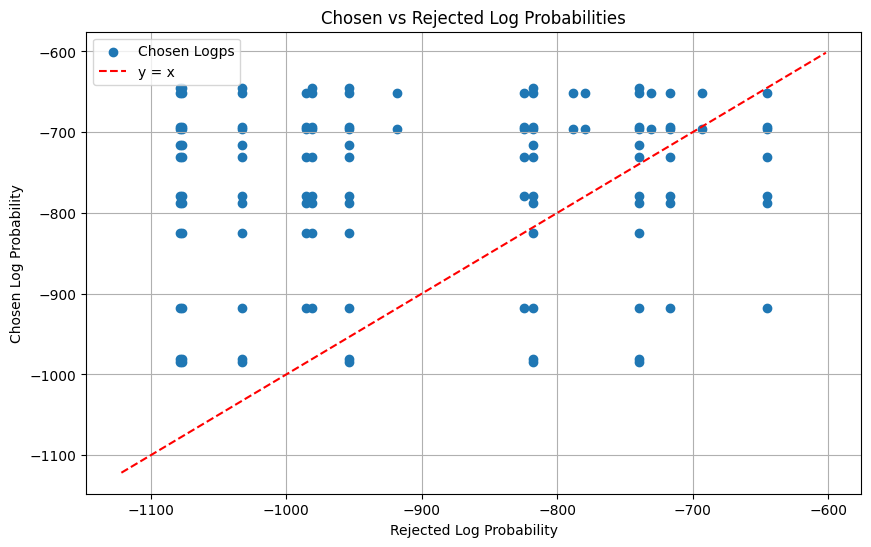

In [ ]:
plot_logps(chosen_logps = list(summary_df['chosen_logps']),
           rejected_logps = list(summary_df['rejected_logps']),
           path='data/')



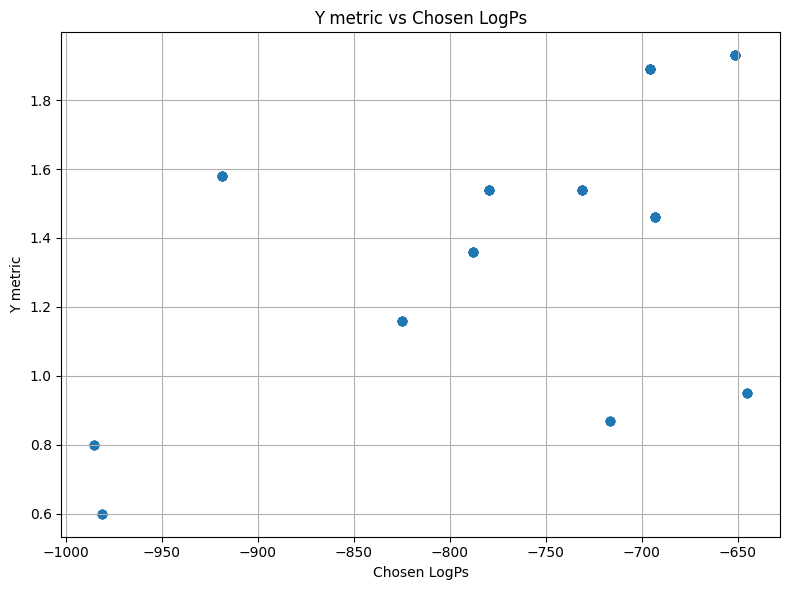

In [18]:
plot_logps_vs_dms(df = summary_df,
                  save_path = 'data/')

In [25]:
print(summary_df['chosen_logps'].unique())
print(summary_df['chosen_target_reg'].unique())

[-651.58538818 -651.58544922 -695.65374756 -695.65380859 -918.37634277
 -918.37640381 -918.37689209 -779.36621094 -779.36572266 -730.88598633
 -730.88586426 -693.12896729 -693.12841797 -788.04626465 -788.04620361
 -824.79052734 -824.79046631 -644.9576416  -716.47009277 -716.47003174
 -985.20935059 -985.20898438 -981.06555176 -981.06561279]
[1.93 1.89 1.58 1.54 1.46 1.36 1.16 0.95 0.87 0.8  0.6 ]
